In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sys
sys.path.append("../")
from src.data.load_data import load_dataset
plt.style.use('ggplot')
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns


from src.models.PCA_Gradual import PcaGradualPattern

In [2]:
# Air Quality
df1 = load_dataset("../data/Unzip/air+quality/AirQualityUCI.xlsx", file_format="excel")
df2 = load_dataset("../data/Unzip/hcv+data/hcvdat_test.csv")
df3 = load_dataset("../data/Unzip/c2k.csv")
df4 = load_dataset("../data/Unzip/hungary_chickenpox.csv")

Dataset successfully loaded. Dimensions: (9357, 15)
Dataset successfully loaded. Dimensions: (615, 12)
Dataset successfully loaded. Dimensions: (3943, 98)
Dataset successfully loaded. Dimensions: (522, 21)


In [3]:
df3 = df3.drop("nr", axis=1)

In [4]:
df2 = df2.drop("Unnamed: 0", axis=1)

In [5]:
# DF 3
df3.replace('?', np.nan, inplace=True)
dfc = df3.loc[: , df3.isna().sum()/df3.shape[0] < 0.5]
print(dfc.shape)
for col in dfc.select_dtypes('object'):
    #print(col, " -------------------------", dfc[col].unique())
    dfc[col] = pd.to_numeric(dfc[col], errors='coerce')
    dfc[col] = dfc[col].fillna(dfc[col].mean()).astype(int)

(3943, 37)


/tmp/ipykernel_22042/2438106928.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc[col] = pd.to_numeric(dfc[col], errors='coerce')
/tmp/ipykernel_22042/2438106928.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc[col] = dfc[col].fillna(dfc[col].mean()).astype(int)
/tmp/ipykernel_22042/2438106928.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

<Axes: >

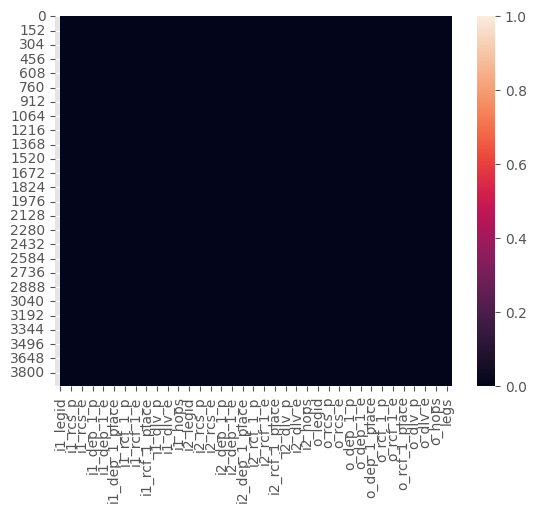

In [6]:
sns.heatmap(dfc.isna())
(dfc.isna().sum()/dfc.shape[1]
).plot(kind='bar')

In [7]:
df3 = dfc.copy()

In [8]:
df = [

    {
        'df': df1,
        'name':'Air Quality' 
    },
    {
        'df': df2,
        'name':'HCV' 
    },
     {
        'df': df3,
        'name':'Cargo 2000' 
    },
     {
        'df': df4,
        'name':'Chickenpox' 
    },
]


In [9]:
PCA_G  = PcaGradualPattern(df)

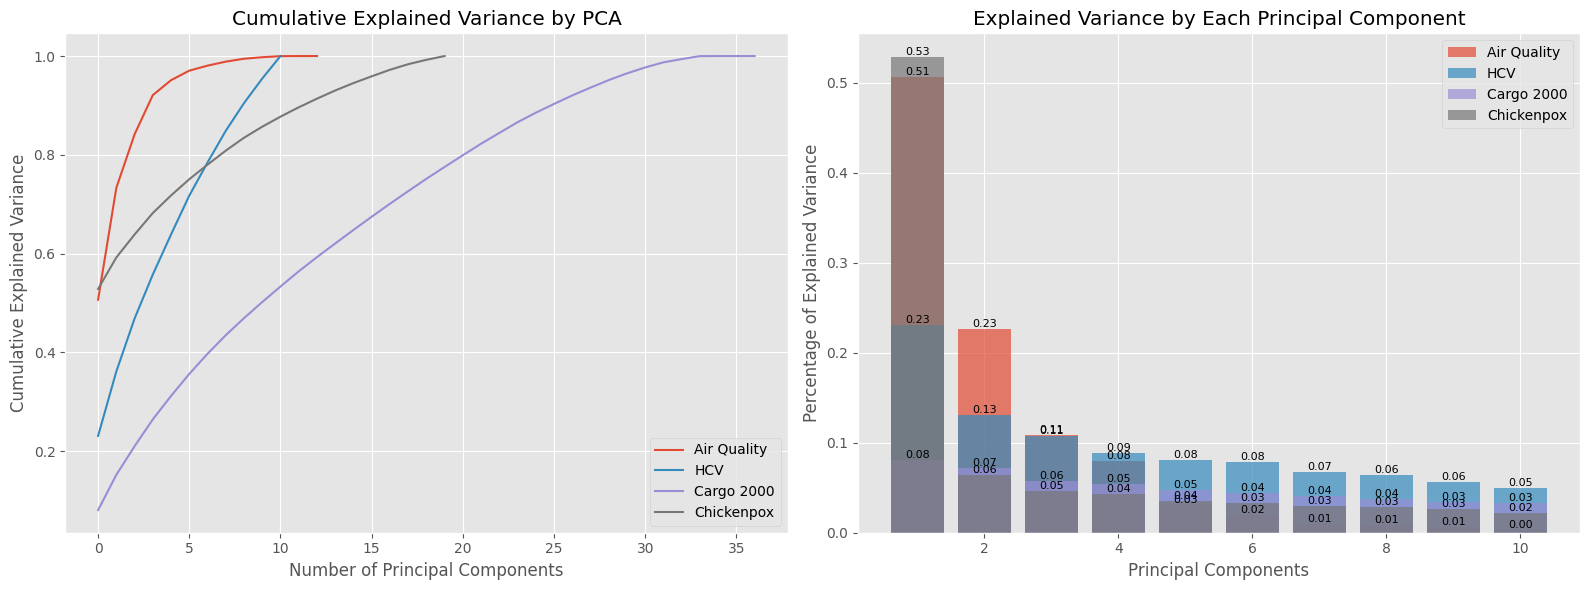

In [10]:
PCA_G.plot_pca_variance_final()

In [11]:
solutions_dfs = PCA_G.apply_pca_and_get_features_importance(0.85)

Nombre de composantes pour expliquer 85.0% de la variance: 4
Nombre de composantes pour expliquer 85.0% de la variance: 9
Nombre de composantes pour expliquer 85.0% de la variance: 24
Nombre de composantes pour expliquer 85.0% de la variance: 10


In [12]:
solutions_dfs[1]

{'df_name': 'HCV',
 'df_loadings':       Composante 1  Composante 2  Composante 3  Composante 4  Composante 5   
 Age      -0.030809      0.520644      0.262468     -0.273107      0.524618  \
 ALB       0.353585     -0.271741     -0.380830     -0.140827      0.087247   
 ALP       0.138069      0.492448      0.069297     -0.030113     -0.309512   
 ALT       0.447927      0.073020      0.175454      0.151259     -0.232278   
 AST       0.370327     -0.006713      0.425320     -0.005698     -0.156315   
 BIL       0.212537     -0.293726      0.394218      0.078880      0.605910   
 CHE       0.367210      0.200914     -0.341558      0.162562      0.013813   
 CHOL      0.193805      0.473366     -0.356330      0.105876      0.295171   
 CREA      0.321119     -0.059985      0.119295      0.584772      0.049369   
 GGT       0.280896      0.029519      0.257532     -0.552973     -0.249264   
 PROT      0.342913     -0.228076     -0.300001     -0.436081      0.154810   
 
       Composant

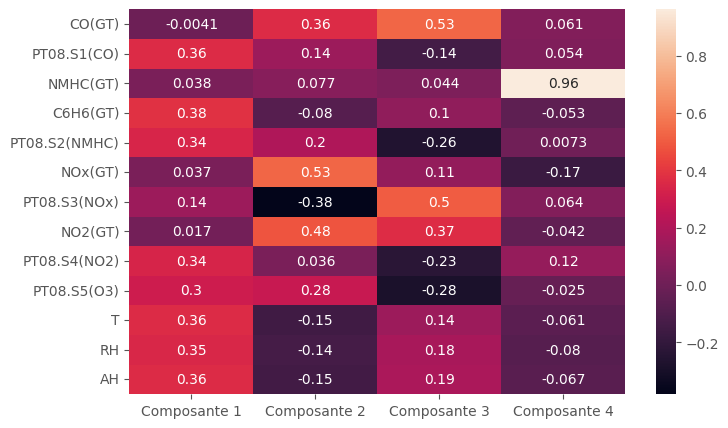

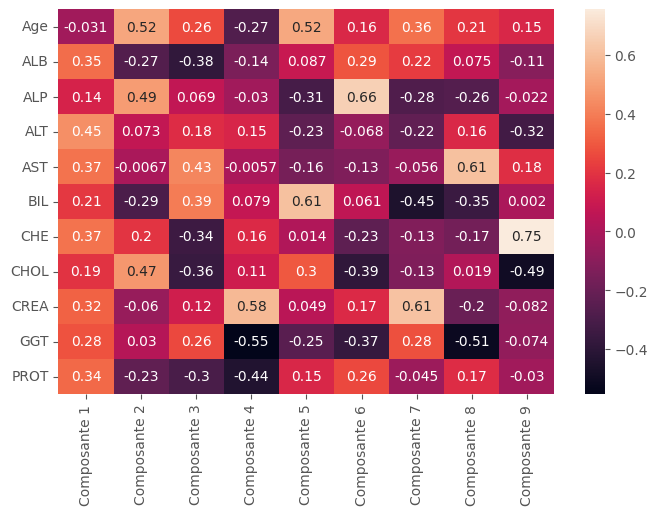

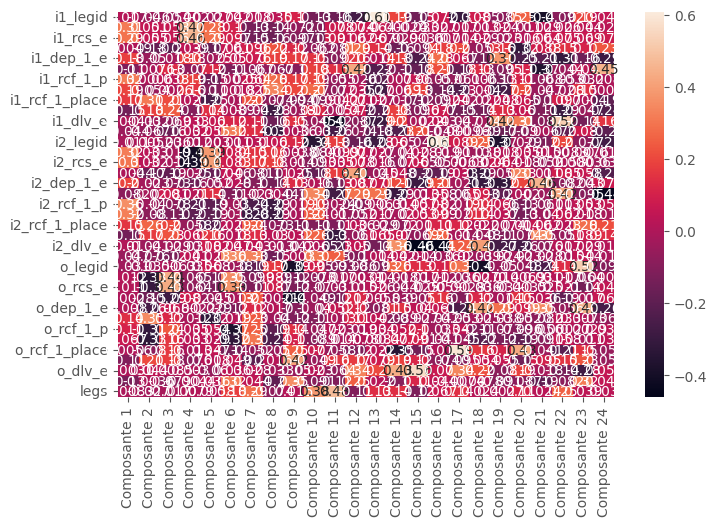

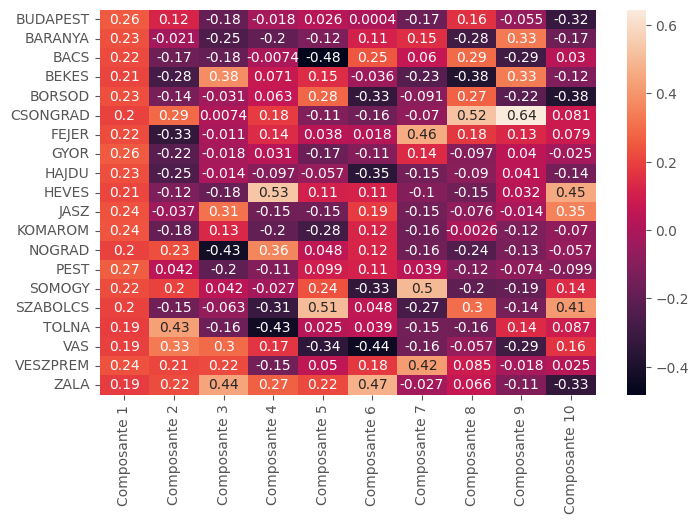

In [13]:
for elm in solutions_dfs:
    plt.figure(figsize=(8,5))
    sns.heatmap(elm["df_loadings"], annot=True)


In [14]:
hcv_cols = PCA_G.extract_significant_variables(df_loadings[1], threshold=0.45)


NameError: name 'df_loadings' is not defined

In [69]:
len(np.unique(hcv_cols))

8

In [70]:
df_loadings = [ elm["df_loadings"] for elm in solutions_dfs]
result_df = PCA_G.process_multiple_dfs(df_loadings, threshold=0.35)

datasets_name = [ "Air Quality","HCV", "Cargo 2000", "Chickenpox"]
num_selected_features = [len(np.unique(np.array(result_df[0]))), len(np.unique(hcv_cols)), len(np.unique(np.array(result_df[2]))),len(np.unique(np.array(result_df[3])))]

num_initial_components = [ elm["n_components"] for elm in solutions_dfs]
num_original_variables = [df1.shape[1], df2.shape[1], df3.shape[1], df4.shape[1]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


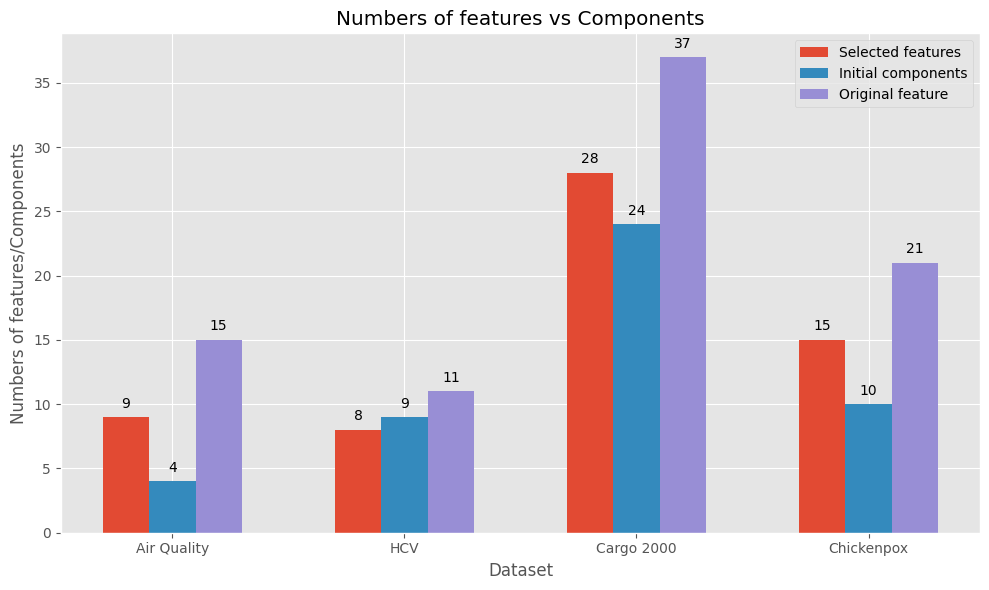

In [71]:
PCA_G.show_size_final_features(datasets_name, num_selected_features, num_initial_components,num_original_variables)

In [54]:
def save_dataframes(dfs, result_df, file_paths):
    for i, df in enumerate(dfs):
        df[np.unique(np.array(result_df[i]))].to_csv(file_paths[i], index=False)
        print("all data are ok")

In [72]:

dfs = [df1, df2, df3, df4]
file_paths = [
    "../data/AfterPCA/Air_quality.csv",
    "../data/AfterPCA/HCV.csv",
    "../data/AfterPCA/Cargo_2000.csv",
    "../data/AfterPCA/Chickenpox.csv"
]

result_df[1] = hcv_cols

save_dataframes(dfs, result_df, file_paths)

all data are ok
all data are ok
all data are ok
all data are ok


In [76]:
df4.head()

,Date,BUDAPEST,BARANYA,BACS,BEKES,BORSOD,CSONGRAD,FEJER,GYOR,HAJDU,...,JASZ,KOMAROM,NOGRAD,PEST,SOMOGY,SZABOLCS,TOLNA,VAS,VESZPREM,ZALA
0,03/01/2005,168,79,30,173,169,42,136,120,162,...,130,57,2,178,66,64,11,29,87,68
1,10/01/2005,157,60,30,92,200,53,51,70,84,...,80,50,29,141,48,29,58,53,68,26
2,17/01/2005,96,44,31,86,93,30,93,84,191,...,64,46,4,157,33,33,24,18,62,44
3,24/01/2005,163,49,43,126,46,39,52,114,107,...,63,54,14,107,66,50,25,21,43,31
4,31/01/2005,122,78,53,87,103,34,95,131,172,...,61,49,11,124,63,56,7,47,85,60


In [82]:
#df1.drop(["Date", "Time"], axis=1).to_csv("../data/Clean/Air_quality.csv", index=False)
#df2.to_csv("../data/Clean/HCV.csv", index=False)
#df3.to_csv("../data/Clean/Cargo_2000.csv", index=False)
#df4.drop(["Date"], axis = 1).to_csv("../data/Clean/Chickenpox.csv", index=False)


In [83]:
pd.read_csv("../data/Clean/Air_quality.csv")

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,3.1,1314.25,-200,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824
9353,2.4,1162.50,-200,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864
9354,2.4,1142.00,-200,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649
9355,2.1,1002.50,-200,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866
